**INTELIGÊNCIA ARTIFICIAL E COMPUTACIONAL**

Prof. Marcones Cleber


In [38]:
# Importando as bibliotecas necessarias para o projeto

import numpy as np
from sklearn.datasets import load_iris
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

import matplotlib.pyplot as plt


## Recebendo os dados

Vamos começar carregando o dataset do iris para a nossa entrada $X$ e saída $y$ dos dados.

In [39]:
iris = load_iris()

In [40]:
# Separando os valores da entrada em X
X = iris.data

In [41]:
y = iris.target

In [42]:
X.shape

(150, 4)

In [43]:
y.shape

(150,)

In [44]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

No nosso modelo iremos ter três saídas na nossa rede, uma delas com a probabilidade de nossos dados pertencerem a classe 0, a outra a classe 1 e por último a classe 2. Para isso, precisamos transformar nossos dados para que possamos ter as três saídas nos nossos dados.

In [45]:
# aplicando o One Hot Enconding com o Keras:
y = tf.keras.utils.to_categorical(y)
y.shape

(150, 3)

In [46]:
y

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

## Dividindo os dados no conjunto de treinamento e teste

O procedimento com o conjunto de dados será o mesmo, primeiro iremos dividir os mesmos em conjunto de treinamento e de teste.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

In [48]:
X_train

array([[4.6, 3.6, 1. , 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [6.7, 3.1, 4.4, 1.4],
       [4.8, 3.4, 1.6, 0.2],
       [4.4, 3.2, 1.3, 0.2],
       [6.3, 2.5, 5. , 1.9],
       [6.4, 3.2, 4.5, 1.5],
       [5.2, 3.5, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.2, 4.1, 1.5, 0.1],
       [5.8, 2.7, 5.1, 1.9],
       [6. , 3.4, 4.5, 1.6],
       [6.7, 3.1, 4.7, 1.5],
       [5.4, 3.9, 1.3, 0.4],
       [5.4, 3.7, 1.5, 0.2],
       [5.5, 2.4, 3.7, 1. ],
       [6.3, 2.8, 5.1, 1.5],
       [6.4, 3.1, 5.5, 1.8],
       [6.6, 3. , 4.4, 1.4],
       [7.2, 3.6, 6.1, 2.5],
       [5.7, 2.9, 4.2, 1.3],
       [7.6, 3. , 6.6, 2.1],
       [5.6, 3. , 4.5, 1.5],
       [5.1, 3.5, 1.4, 0.2],
       [7.7, 2.8, 6.7, 2. ],
       [5.8, 2.7, 4.1, 1. ],
       [5.2, 3.4, 1.4, 0.2],
       [5. , 3.5, 1.3, 0.3],
       [5.1, 3.8, 1.9, 0.4],
       [5. , 2. , 3.5, 1. ],
       [6.3, 2.7, 4.9, 1.8],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [5.6, 2

In [49]:
X_test

array([[6.1, 2.8, 4.7, 1.2],
       [5.7, 3.8, 1.7, 0.3],
       [7.7, 2.6, 6.9, 2.3],
       [6. , 2.9, 4.5, 1.5],
       [6.8, 2.8, 4.8, 1.4],
       [5.4, 3.4, 1.5, 0.4],
       [5.6, 2.9, 3.6, 1.3],
       [6.9, 3.1, 5.1, 2.3],
       [6.2, 2.2, 4.5, 1.5],
       [5.8, 2.7, 3.9, 1.2],
       [6.5, 3.2, 5.1, 2. ],
       [4.8, 3. , 1.4, 0.1],
       [5.5, 3.5, 1.3, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.1, 3.8, 1.5, 0.3],
       [6.3, 3.3, 4.7, 1.6],
       [6.5, 3. , 5.8, 2.2],
       [5.6, 2.5, 3.9, 1.1],
       [5.7, 2.8, 4.5, 1.3],
       [6.4, 2.8, 5.6, 2.2],
       [4.7, 3.2, 1.6, 0.2],
       [6.1, 3. , 4.9, 1.8],
       [5. , 3.4, 1.6, 0.4],
       [6.4, 2.8, 5.6, 2.1],
       [7.9, 3.8, 6.4, 2. ],
       [6.7, 3. , 5.2, 2.3],
       [6.7, 2.5, 5.8, 1.8],
       [6.8, 3.2, 5.9, 2.3],
       [4.8, 3. , 1.4, 0.3],
       [4.8, 3.1, 1.6, 0.2]])

In [50]:
y_train

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1

In [51]:
y_test

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.]])

Também iremos ajustar a escala dos nossos dados.

In [52]:
# ajustando a escala dos nossos dados com MinMaxScaler()
ajuste_escala = MinMaxScaler().fit(X_train)
X_train_scaled = ajuste_escala.transform(X_train)
X_test_scaled = ajuste_escala.transform(X_test)

In [53]:
X_train.max()

np.float64(7.7)

In [54]:
X_train_scaled.max()

np.float64(1.0)

## Criando a Rede Neural com o Keras

Vamos definir um modelo com as seguintes camadas:

*   Entrada com 4 valores (4 atributos dos nossos dados)
*   Primeira camada com 8 neurônios e função de ativação por ReLU
*   Camada Oculta com 8 neurônios e função de ativação por ReLU
*   Saída da rede com 3 neurônios e função de ativação por softmax


In [55]:
# Criando o modelo para fazer a classificação dos dados
model = Sequential()

model.add(Input(shape = (4,),
                name = "Entrada")) # Camada de Entrada dos nossos dados

model.add(Dense(8,
                bias_initializer = 'zeros', # inicializando o bias com valores nulos
                kernel_initializer='glorot_uniform', # iniciando o kernel com o glorot_uniform
                use_bias=True, # Queremos o uso do bias
                activation='relu', name = 'Primeira_Camada_Oculta',))

model.add(Dense(8,
                bias_initializer = 'zeros', # inicializando o bias com valores nulos
                kernel_initializer='glorot_uniform', # iniciando o kernel com o glorot_uniform
                use_bias=True, # Queremos o uso do bias
                activation='relu', name = 'Segunda_Camada_Oculta'))

model.add(Dense(3,
                bias_initializer = 'zeros', # inicializando o bias com valores nulos
                kernel_initializer='glorot_uniform', # iniciando o kernel com o glorot_uniform
                use_bias=True, # Queremos o uso do bias
                activation='softmax', name = 'Saida'))


In [56]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Primeira_Camada_Oculta (Dense)  │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Segunda_Camada_Oculta (Dense)   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida (Dense)                   │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139 (556.00 B)

 Trainable params: 139 (556.00 B)

 Non-trainable params: 0 (0.00 B)

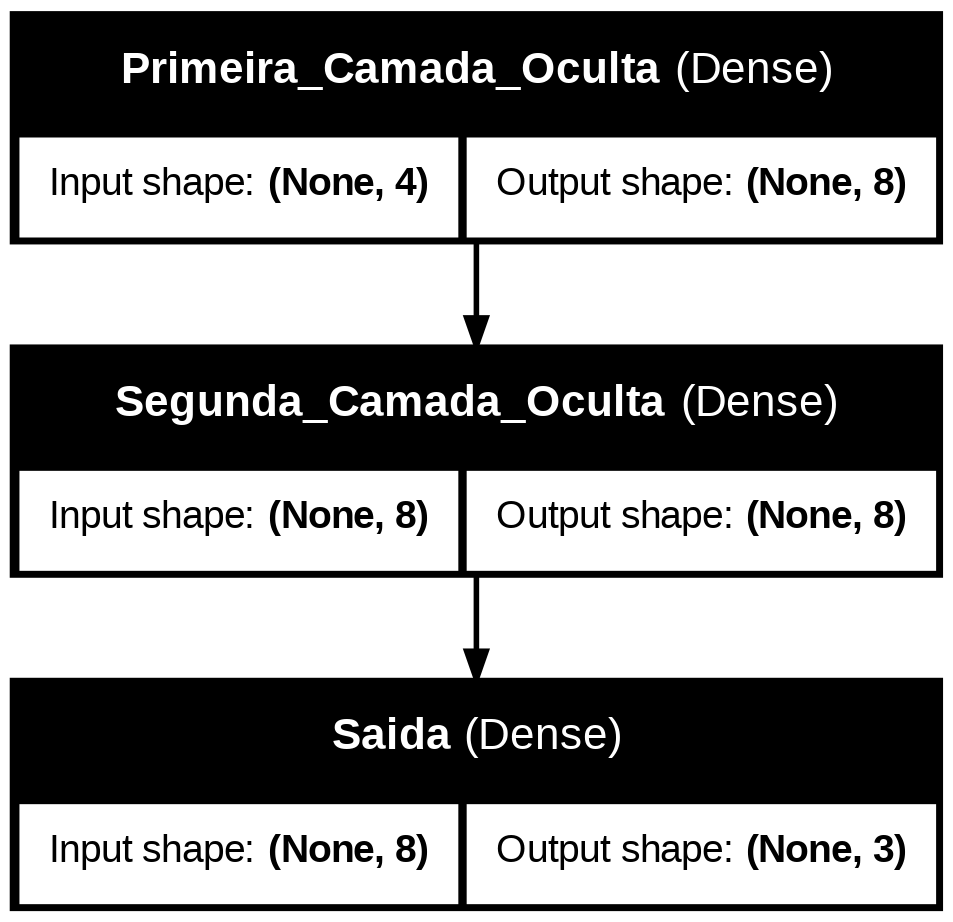

In [57]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

## Realizando o treinamento do modelo

Vamos fazer o treinamento do nosso modelo usando o categorical crossentropy como função de custo, SGD como algoritmo de otimização dos parâmetros, taxa de aprendizado de 0,001 e métrica no treinamento com a acurácia.

In [58]:
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), metrics=['accuracy'])

Realizando o treinamento com 1500 épocas, com batch_size de 10 e 10% dos dados utilizados para a validação do modelo.

In [59]:
# Vamos fazer o treinamento utilizando 1000 epocas!
history = model.fit(X_train_scaled,y_train,epochs=1500, verbose=2, batch_size=10, validation_split=0.1)

Epoch 1/1500
11/11 - 2s - 158ms/step - accuracy: 0.0093 - loss: 1.1557 - val_accuracy: 0.0000e+00 - val_loss: 1.1539
Epoch 2/1500
11/11 - 0s - 8ms/step - accuracy: 0.0093 - loss: 1.1525 - val_accuracy: 0.0000e+00 - val_loss: 1.1503
Epoch 3/1500
11/11 - 0s - 8ms/step - accuracy: 0.0093 - loss: 1.1495 - val_accuracy: 0.0000e+00 - val_loss: 1.1468
Epoch 4/1500
11/11 - 0s - 8ms/step - accuracy: 0.0185 - loss: 1.1467 - val_accuracy: 0.0000e+00 - val_loss: 1.1434
Epoch 5/1500
11/11 - 0s - 9ms/step - accuracy: 0.0185 - loss: 1.1439 - val_accuracy: 0.0000e+00 - val_loss: 1.1402
Epoch 6/1500
11/11 - 0s - 12ms/step - accuracy: 0.0370 - loss: 1.1413 - val_accuracy: 0.0000e+00 - val_loss: 1.1371
Epoch 7/1500
11/11 - 0s - 8ms/step - accuracy: 0.0556 - loss: 1.1388 - val_accuracy: 0.0000e+00 - val_loss: 1.1342
Epoch 8/1500
11/11 - 0s - 8ms/step - accuracy: 0.0556 - loss: 1.1367 - val_accuracy: 0.0000e+00 - val_loss: 1.1317
Epoch 9/1500
11/11 - 0s - 8ms/step - accuracy: 0.0648 - loss: 1.1349 - val_ac

Vamos plotar um gráfico para analisar o comportamento da função custo durante o treinamento:

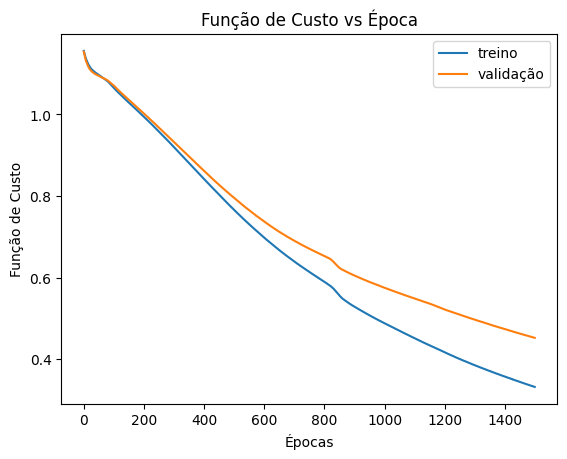

In [60]:
# Plotando o MSE para cada época de treinamento
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Função de Custo vs Época')
plt.ylabel('Função de Custo')
plt.xlabel('Épocas')
plt.legend(['treino', 'validação'], loc='upper right')
plt.show()

Podemos ver que o valor da função custo manteve o mesmo padrão para o conjunto de treinamento e de validação, o que indica que não houver overfitting no nosso treinamento

Salvando o modelo que foi criado:

In [61]:
model.save('classificador_iris.h5')

## Métricas de Desempenho

Vamos checar o valor de saída da rede para o conjunto de teste:

In [62]:
model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


array([[1.78989153e-02, 5.95675111e-01, 3.86426032e-01],
       [9.01547194e-01, 9.19625238e-02, 6.49026036e-03],
       [1.60446180e-05, 8.49896222e-02, 9.14994359e-01],
       [1.43100489e-02, 5.60195625e-01, 4.25494343e-01],
       [5.32455370e-03, 4.71147448e-01, 5.23527980e-01],
       [8.73140454e-01, 1.17786400e-01, 9.07315593e-03],
       [7.21855164e-02, 6.74114108e-01, 2.53700376e-01],
       [6.16701087e-04, 2.51692921e-01, 7.47690439e-01],
       [5.02812397e-03, 4.53066677e-01, 5.41905224e-01],
       [4.39926572e-02, 6.60789132e-01, 2.95218229e-01],
       [2.24501663e-03, 3.65879804e-01, 6.31875157e-01],
       [8.88618350e-01, 1.02849253e-01, 8.53233784e-03],
       [8.99081945e-01, 9.38616097e-02, 7.05642300e-03],
       [8.92589033e-01, 9.94192436e-02, 7.99176656e-03],
       [9.00957823e-01, 9.20346007e-02, 7.00763846e-03],
       [1.14511475e-02, 5.38968801e-01, 4.49580103e-01],
       [5.01059869e-04, 2.41282538e-01, 7.58216441e-01],
       [5.12756966e-02, 6.72223

O padrão obtido seria a porcentagem de cada um dos valores do conjunto de teste pertencerem a cada uma das classes (0, 1 e 2). Aquele com o maior valor, é a classe com a qual o nosso modelo fez a previsão. Vamos agora transforma isso em um array com os valores das classes e não a probabilidade de cada uma delas.

In [63]:
y_pred = model.predict(X_test_scaled).argmax(axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([1, 0, 2, 1, 2, 0, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [64]:
y_test.argmax(axis=1)

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

Vamos agora checar a matriz de confusão dos nossos dados:

In [65]:
cm_rn = confusion_matrix(y_test.argmax(axis=1), y_pred, labels = [0,1,2])
cm_rn

array([[10,  0,  0],
       [ 0,  7,  2],
       [ 0,  0, 11]])

<Figure size 1500x500 with 0 Axes>

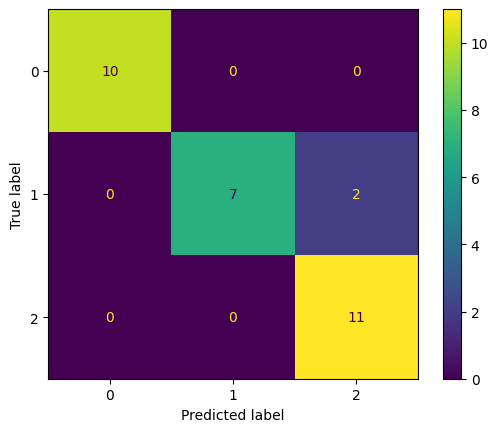

In [66]:
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = cm_rn, display_labels=[0,1,2])
disp.plot(values_format='d')

Por fim, vamos obter as nossas métricas de precisão, revocação e acurácia:

In [67]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test.argmax(axis=1), y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.78      0.88         9
           2       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

